# Level 3 - Task 3: Data Visualization

## Objective

Visualize important patterns and relationships in the Zomato dataset to
better understand restaurant ratings, customer engagement, cuisine
preferences, and other relevant features.

### Visualization Areas

- Distribution of restaurant ratings
- Comparison of average ratings across cuisines
- Comparison of average ratings across cities
- Relationship between votes and restaurant ratings
- Relationship between price range and restaurant ratings
- Relationship between important features and the target variable

### Expected Outcome

Create clear and informative visualizations that reveal important
patterns, trends, and relationships in restaurant ratings and customer
preferences.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
df = pd.read_csv("Outputs/feature_engineered_zomato.csv")

print("Dataset loaded successfully.")
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully.
Shape: (9551, 27)


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Aggregate rating,Rating color,Rating text,Votes,Restaurant Name Length,Address Length,Has Table Booking Encoded,Has Online Delivery Encoded,Price Range Category,Log Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,4.8,Dark Green,Excellent,314,16,71,1,0,High,5.752573
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,4.5,Dark Green,Excellent,591,16,67,1,0,High,6.383507
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,4.4,Green,Very Good,270,22,56,1,0,Very High,5.602119
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,4.9,Dark Green,Excellent,365,4,70,0,0,Very High,5.902633
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,4.8,Dark Green,Excellent,229,11,64,1,0,Very High,5.438079


In [3]:
print("Dataset Information")
print("=" * 60)

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nMissing Values:")
display(df.isnull().sum())

print("\nRelevant Columns:")
display(df[
    [
        "Aggregate rating",
        "Votes",
        "Price range",
        "Cuisines",
        "City"
    ]
].head())

Dataset Information
Rows: 9551
Columns: 27

Missing Values:


Restaurant ID                  0
Restaurant Name                0
Country Code                   0
City                           0
Address                        0
Locality                       0
Locality Verbose               0
Longitude                      0
Latitude                       0
Cuisines                       0
Average Cost for two           0
Currency                       0
Has Table booking              0
Has Online delivery            0
Is delivering now              0
Switch to order menu           0
Price range                    0
Aggregate rating               0
Rating color                   0
Rating text                    0
Votes                          0
Restaurant Name Length         0
Address Length                 0
Has Table Booking Encoded      0
Has Online Delivery Encoded    0
Price Range Category           0
Log Votes                      0
dtype: int64


Relevant Columns:


,Aggregate rating,Votes,Price range,Cuisines,City
0,4.8,314,3,"French, Japanese, Desserts",Makati City
1,4.5,591,3,Japanese,Makati City
2,4.4,270,4,"Seafood, Asian, Filipino, Indian",Mandaluyong City
3,4.9,365,4,"Japanese, Sushi",Mandaluyong City
4,4.8,229,4,"Japanese, Korean",Mandaluyong City


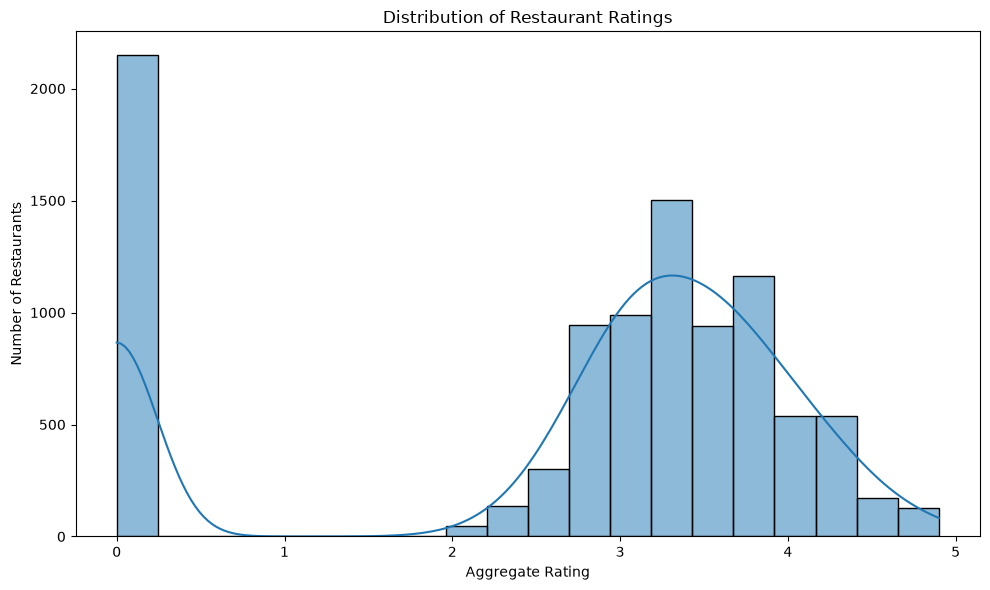

In [4]:

# RATING DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="Aggregate rating",
    bins=20,
    kde=True
)

plt.title("Distribution of Restaurant Ratings")
plt.xlabel("Aggregate Rating")
plt.ylabel("Number of Restaurants")
plt.tight_layout()
plt.show()

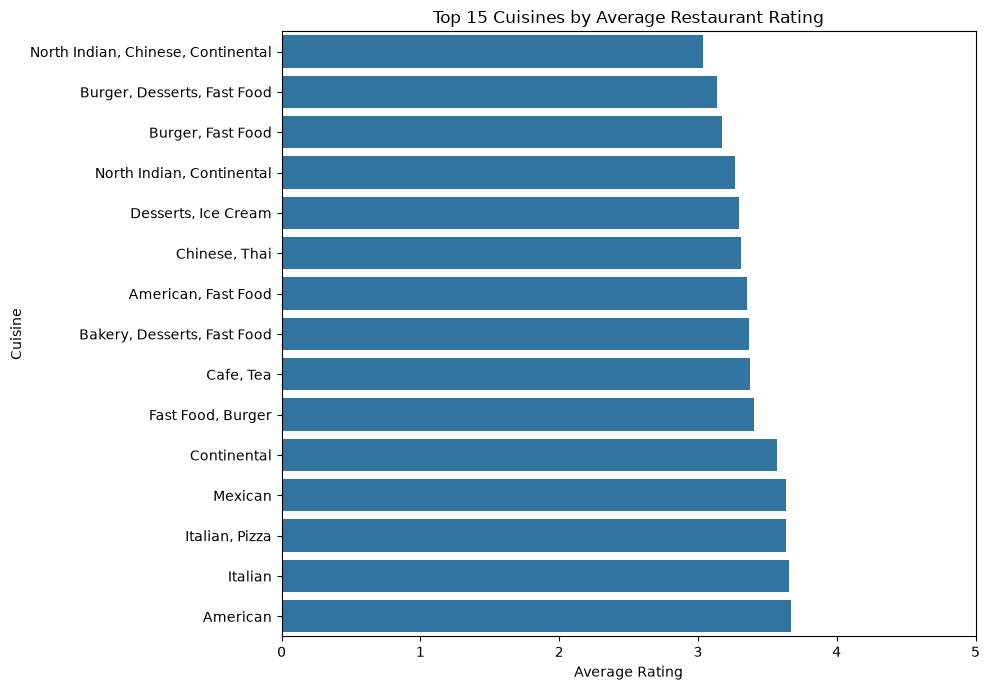

In [5]:

# AVERAGE RATING BY CUISINE
# ============================================================

cuisine_rating = (
    df.groupby("Cuisines")
      .agg(
          Average_Rating=("Aggregate rating", "mean"),
          Restaurant_Count=("Restaurant Name", "count")
      )
      .reset_index()
)

# Consider cuisines with at least 20 restaurants
reliable_cuisines = cuisine_rating[
    cuisine_rating["Restaurant_Count"] >= 20
].copy()

top_cuisines = reliable_cuisines.sort_values(
    by="Average_Rating",
    ascending=False
).head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_cuisines.sort_values("Average_Rating"),
    x="Average_Rating",
    y="Cuisines"
)

plt.title("Top 15 Cuisines by Average Restaurant Rating")
plt.xlabel("Average Rating")
plt.ylabel("Cuisine")
plt.xlim(0, 5)
plt.tight_layout()
plt.show()

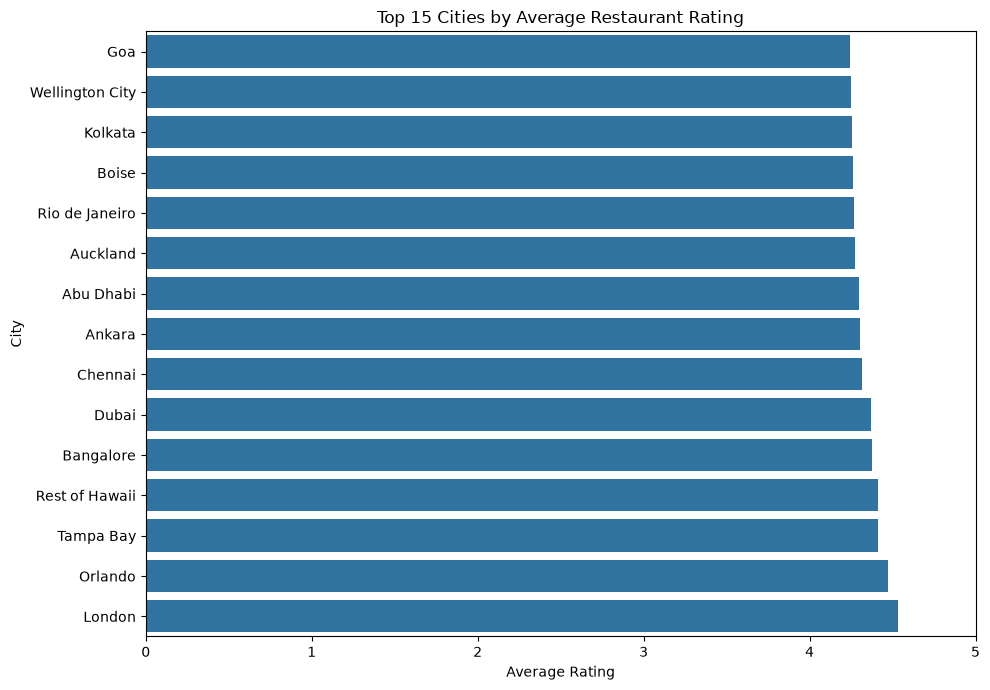

In [6]:

# AVERAGE RATING BY CITY
# ============================================================

city_rating = (
    df.groupby("City")
      .agg(
          Average_Rating=("Aggregate rating", "mean"),
          Restaurant_Count=("Restaurant Name", "count")
      )
      .reset_index()
)

# Consider cities with at least 20 restaurants
reliable_cities = city_rating[
    city_rating["Restaurant_Count"] >= 20
].copy()

top_cities = reliable_cities.sort_values(
    by="Average_Rating",
    ascending=False
).head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_cities.sort_values("Average_Rating"),
    x="Average_Rating",
    y="City"
)

plt.title("Top 15 Cities by Average Restaurant Rating")
plt.xlabel("Average Rating")
plt.ylabel("City")
plt.xlim(0, 5)
plt.tight_layout()
plt.show()

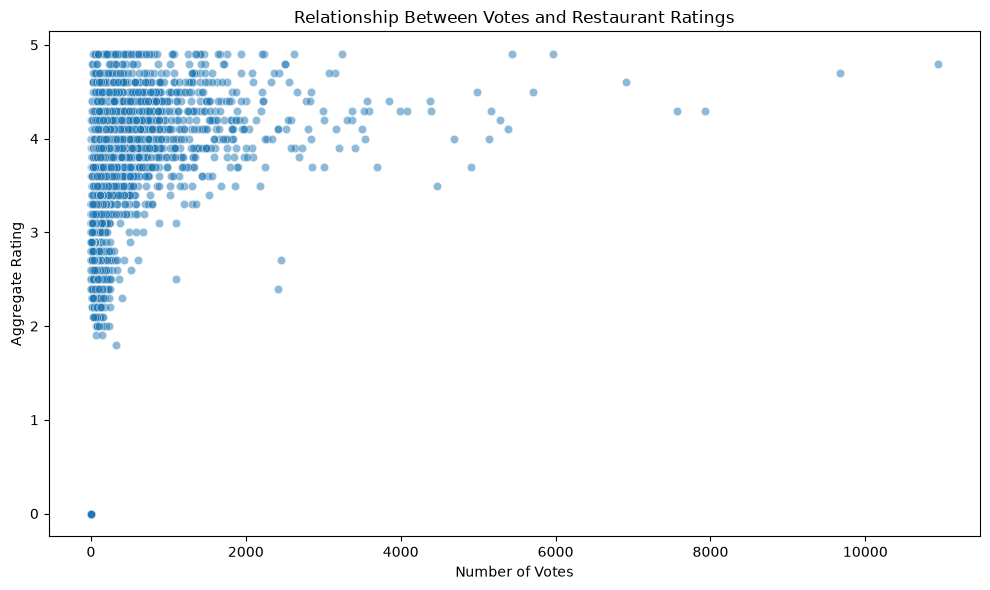

In [7]:

# RELATIONSHIP BETWEEN VOTES AND RATING
# ============================================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Votes",
    y="Aggregate rating",
    alpha=0.5
)

plt.title("Relationship Between Votes and Restaurant Ratings")
plt.xlabel("Number of Votes")
plt.ylabel("Aggregate Rating")
plt.tight_layout()
plt.show()

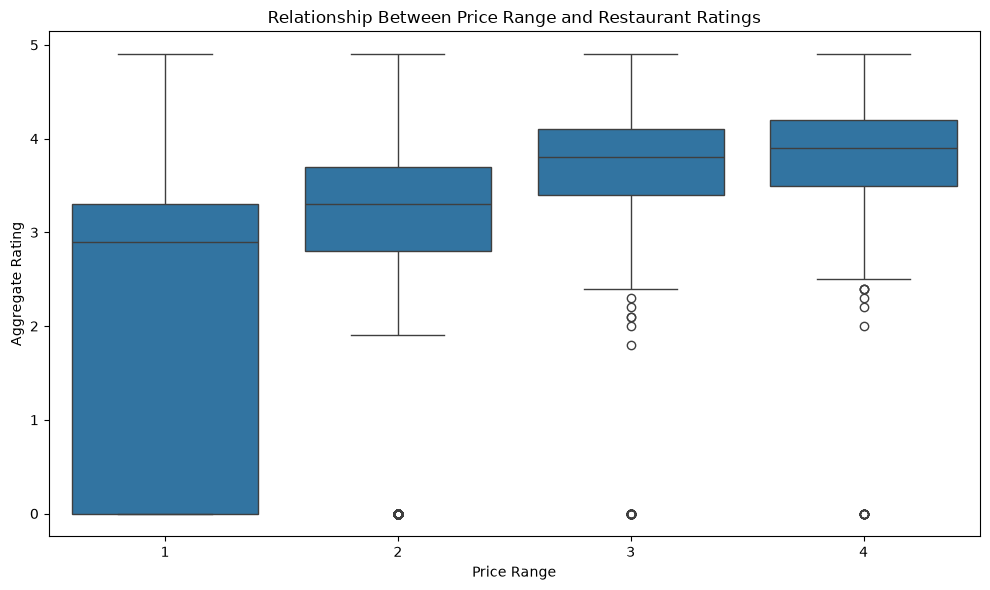

In [8]:

# RELATIONSHIP BETWEEN PRICE RANGE AND RATING
# ============================================================

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Price range",
    y="Aggregate rating"
)

plt.title("Relationship Between Price Range and Restaurant Ratings")
plt.xlabel("Price Range")
plt.ylabel("Aggregate Rating")
plt.tight_layout()
plt.show()

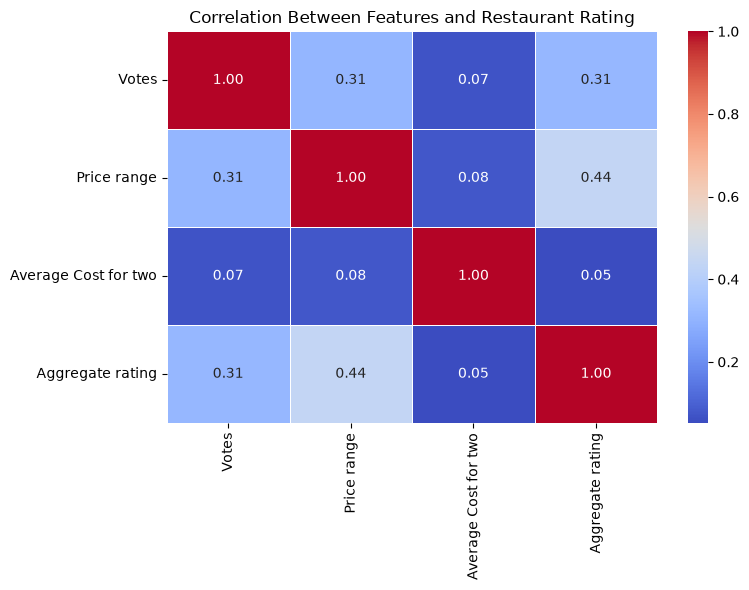

In [9]:

# FEATURE RELATIONSHIP WITH TARGET
# ============================================================

correlation_data = df[
    [
        "Votes",
        "Price range",
        "Average Cost for two",
        "Aggregate rating"
    ]
].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_data,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Between Features and Restaurant Rating")
plt.tight_layout()
plt.show()

In [10]:

# SAVE VISUALIZATION ANALYSIS DATA
# ============================================================

rating_distribution = (
    df["Aggregate rating"]
    .value_counts()
    .sort_index()
    .reset_index()
)

rating_distribution.columns = [
    "Aggregate_Rating",
    "Restaurant_Count"
]

city_rating.to_csv(
    "Outputs/task3_city_rating_analysis.csv",
    index=False
)

cuisine_rating.to_csv(
    "Outputs/task3_cuisine_rating_analysis.csv",
    index=False
)

rating_distribution.to_csv(
    "Outputs/task3_rating_distribution.csv",
    index=False
)

correlation_data.to_csv(
    "Outputs/task3_feature_rating_correlation.csv"
)

print("Task 3 analysis files saved successfully.")

Task 3 analysis files saved successfully.


In [11]:

# KEY FINDINGS
# ============================================================

highest_rated_city = reliable_cities.loc[
    reliable_cities["Average_Rating"].idxmax()
]

highest_rated_cuisine = reliable_cuisines.loc[
    reliable_cuisines["Average_Rating"].idxmax()
]

highest_correlation = correlation_data[
    "Aggregate rating"
].drop("Aggregate rating").abs().idxmax()

print("=" * 70)
print("KEY FINDINGS FROM DATA VISUALIZATION")
print("=" * 70)

print(
    f"\nHighest-rated city: {highest_rated_city['City']}"
    f" | Average Rating: {highest_rated_city['Average_Rating']:.2f}"
)

print(
    f"Highest-rated cuisine: {highest_rated_cuisine['Cuisines']}"
    f" | Average Rating: {highest_rated_cuisine['Average_Rating']:.2f}"
)

print(
    f"Feature with strongest correlation with rating: "
    f"{highest_correlation}"
    f" | Correlation: {correlation_data.loc[highest_correlation, 'Aggregate rating']:.2f}"
)

print("\nVisualization analysis completed successfully.")

KEY FINDINGS FROM DATA VISUALIZATION

Highest-rated city: London | Average Rating: 4.54
Highest-rated cuisine: American | Average Rating: 3.67
Feature with strongest correlation with rating: Price range | Correlation: 0.44

Visualization analysis completed successfully.


In [15]:

# CONCLUSION
# ============================================================

print("""
CONCLUSION
==========

The data visualization analysis provided a clear understanding of
restaurant ratings and their relationships with important features
in the Zomato dataset.

- The rating distribution visualization shows how restaurant ratings
  are distributed across the dataset.

- The cuisine-wise comparison highlights differences in average
  restaurant ratings across cuisines.

- The city-wise analysis identifies cities with comparatively higher
  average restaurant ratings.

- The votes-versus-rating visualization helps examine the relationship
  between customer engagement and restaurant ratings.

- The price-range analysis shows how ratings vary across different
  restaurant price categories.

- The correlation analysis provides insights into the relationships
  between numerical features and the aggregate restaurant rating.

Overall, the visualizations make the dataset easier to interpret and
help identify meaningful patterns that can support further restaurant
and customer preference analysis.
""")




CONCLUSION

The data visualization analysis provided a clear understanding of
restaurant ratings and their relationships with important features
in the Zomato dataset.

- The rating distribution visualization shows how restaurant ratings
  are distributed across the dataset.

- The cuisine-wise comparison highlights differences in average
  restaurant ratings across cuisines.

- The city-wise analysis identifies cities with comparatively higher
  average restaurant ratings.

- The votes-versus-rating visualization helps examine the relationship
  between customer engagement and restaurant ratings.

- The price-range analysis shows how ratings vary across different
  restaurant price categories.

- The correlation analysis provides insights into the relationships
  between numerical features and the aggregate restaurant rating.

Overall, the visualizations make the dataset easier to interpret and
help identify meaningful patterns that can support further restaurant
and customer prefere

In [16]:

# VERIFY OUTPUT FILES
# ============================================================

import os

output_files = [
    "Outputs/task3_city_rating_analysis.csv",
    "Outputs/task3_cuisine_rating_analysis.csv",
    "Outputs/task3_rating_distribution.csv",
    "Outputs/task3_feature_rating_correlation.csv"
]

print("=" * 70)
print("TASK 3 OUTPUT VERIFICATION")
print("=" * 70)

all_files_exist = True

for file in output_files:
    if os.path.exists(file):
        print(f"✓ FOUND: {file}")
    else:
        print(f"✗ MISSING: {file}")
        all_files_exist = False

print("\n" + "=" * 70)

if all_files_exist:
    print("✓ All Task 3 output files were created successfully.")
else:
    print("✗ Some output files are missing. Please check the previous cells.")

TASK 3 OUTPUT VERIFICATION
✓ FOUND: Outputs/task3_city_rating_analysis.csv
✓ FOUND: Outputs/task3_cuisine_rating_analysis.csv
✓ FOUND: Outputs/task3_rating_distribution.csv
✓ FOUND: Outputs/task3_feature_rating_correlation.csv

✓ All Task 3 output files were created successfully.


In [17]:

# VERIFY OUTPUT CONTENTS
# ============================================================

rating_check = pd.read_csv(
    "Outputs/task3_rating_distribution.csv"
)

cuisine_check = pd.read_csv(
    "Outputs/task3_cuisine_rating_analysis.csv"
)

city_check = pd.read_csv(
    "Outputs/task3_city_rating_analysis.csv"
)

correlation_check = pd.read_csv(
    "Outputs/task3_feature_rating_correlation.csv",
    index_col=0
)

print("=" * 70)
print("TASK 3 OUTPUT CONTENT VERIFICATION")
print("=" * 70)

print("\nRating Distribution:")
print("Shape:", rating_check.shape)
display(rating_check.head())

print("\nCuisine Rating Analysis:")
print("Shape:", cuisine_check.shape)
display(cuisine_check.head())

print("\nCity Rating Analysis:")
print("Shape:", city_check.shape)
display(city_check.head())

print("\nFeature-Rating Correlation:")
print("Shape:", correlation_check.shape)
display(correlation_check)

print("\n✓ All Task 3 output files contain valid data.")

TASK 3 OUTPUT CONTENT VERIFICATION

Rating Distribution:
Shape: (33, 2)


,Aggregate_Rating,Restaurant_Count
0,0.0,2148
1,1.8,1
2,1.9,2
3,2.0,7
4,2.1,15



Cuisine Rating Analysis:
Shape: (1825, 3)


,Cuisines,Average_Rating,Restaurant_Count
0,Afghani,0.725,4
1,"Afghani, Mughlai, Chinese",0.000,1
2,"Afghani, North Indian",0.000,1
3,"Afghani, North Indian, Pakistani, Arabian",0.000,1
4,African,4.700,1



City Rating Analysis:
Shape: (141, 3)


,City,Average_Rating,Restaurant_Count
0,Abu Dhabi,4.300000,20
1,Agra,3.965000,20
2,Ahmedabad,4.161905,21
3,Albany,3.555000,20
4,Allahabad,3.395000,20



Feature-Rating Correlation:
Shape: (4, 4)


,Votes,Price range,Average Cost for two,Aggregate rating
Votes,1.000000,0.309444,0.067783,0.313691
Price range,0.309444,1.000000,0.075083,0.437944
Average Cost for two,0.067783,0.075083,1.000000,0.051792
Aggregate rating,0.313691,0.437944,0.051792,1.000000



✓ All Task 3 output files contain valid data.
